In [1]:
#data handling
import numpy as np
import pandas as pd
#data visualization
import seaborn as sns
import matplotlib.pyplot as plt
#train test split
from sklearn.model_selection import train_test_split
#preprocessing the data
#handling missig values
from sklearn.impute import SimpleImputer
#for combining scaling and encode
from sklearn.compose import ColumnTransformer
#encoding categorical data
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
#feature scaling
from sklearn.preprocessing import StandardScaler,MinMaxScaler
#Feature Selection
from sklearn.feature_selection import SelectKBest ,f_regression
from sklearn.feature_selection import chi2
#or 
from sklearn.ensemble import RandomForestClassifier
#Model Selection
from sklearn.pipeline import Pipeline
#classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

#Regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
#model training(no library needed)
#prediction(no)
#ModelMetrics
#classification metrics
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
#regression metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
#model saving
import pickle
import joblib

In [2]:
churn=pd.read_csv('C:/Users/user/Downloads/COD_TASK_3_Customer Churn Prediction/Churn_Modelling.csv')

In [3]:
churn

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
churn=churn.drop(columns=['RowNumber','CustomerId','Surname'])
churn

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [5]:
churn["Balance_per_product"]=churn['Balance']/churn['NumOfProducts']

In [6]:
churn["Is Senior"] = (churn['Age']>60).astype(int)

In [7]:
# This creates 4 bins with an equal number of customers in each
churn['Credit_Category'] = pd.qcut(churn['CreditScore'], q=4, labels=['Low', 'Medium', 'High', 'Top'])

In [8]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   CreditScore          10000 non-null  int64   
 1   Geography            10000 non-null  object  
 2   Gender               10000 non-null  object  
 3   Age                  10000 non-null  int64   
 4   Tenure               10000 non-null  int64   
 5   Balance              10000 non-null  float64 
 6   NumOfProducts        10000 non-null  int64   
 7   HasCrCard            10000 non-null  int64   
 8   IsActiveMember       10000 non-null  int64   
 9   EstimatedSalary      10000 non-null  float64 
 10  Exited               10000 non-null  int64   
 11  Balance_per_product  10000 non-null  float64 
 12  Is Senior            10000 non-null  int64   
 13  Credit_Category      10000 non-null  category
dtypes: category(1), float64(3), int64(8), object(2)
memory usage: 1.0+ MB


In [9]:
churn['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

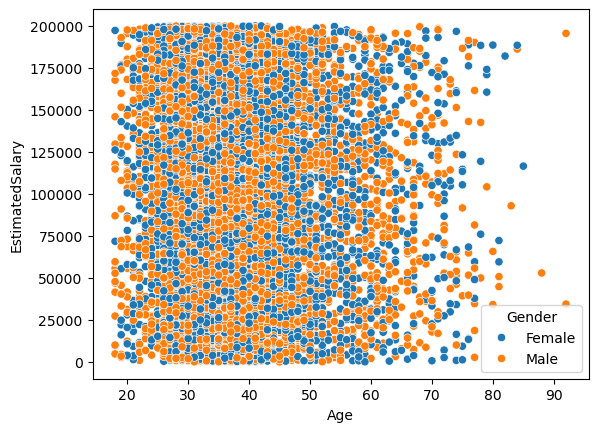

In [10]:
sns.scatterplot(data=churn,x='Age',y='EstimatedSalary',hue='Gender')
plt.show()

<Axes: xlabel='EstimatedSalary', ylabel='Geography'>

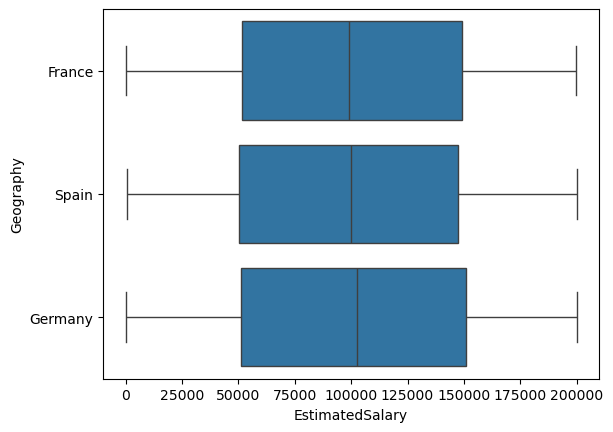

In [11]:
sns.boxplot(x='EstimatedSalary',y='Geography',data=churn)

<Axes: xlabel='EstimatedSalary', ylabel='Gender'>

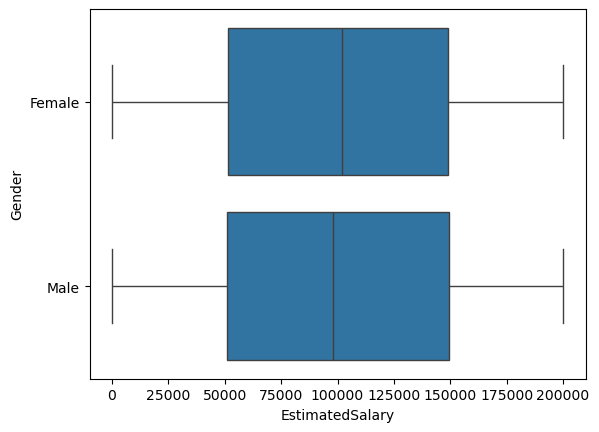

In [12]:
sns.boxplot(x='EstimatedSalary',y='Gender',data=churn)

<Axes: xlabel='EstimatedSalary', ylabel='Count'>

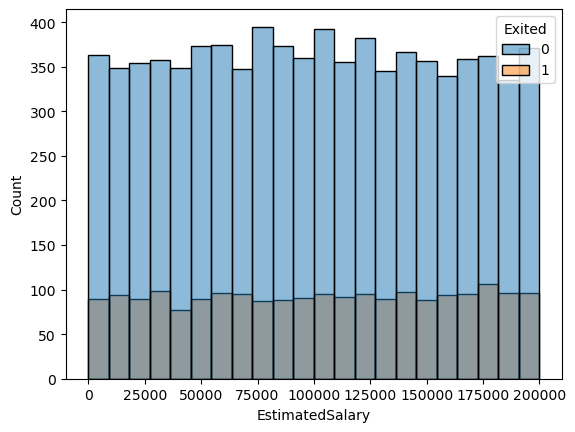

In [13]:
sns.histplot(data=churn, x='EstimatedSalary', hue='Exited')

In [14]:
X = churn.drop('Exited', axis=1)   # Features
y = churn['Exited']                # Target

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary','Balance_per_product','Is Senior']
binary_features = ['HasCrCard', 'IsActiveMember']  # already 0/1
binary_encode_features = ['Gender']                # encode 0/1 manually
categorical_features = ['Geography']               # one-hot encoding
credit_rank_order = [['Low', 'Medium', 'High', 'Top']]

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('geo', OneHotEncoder(drop='first'), ['Geography']),
        ('gender', OneHotEncoder(drop='if_binary'), ['Gender']),  # binary encoding via OHE
        ('credit_ordinal', OrdinalEncoder(categories=credit_rank_order), ['Credit_Category'])
    ],
    remainder='passthrough'  # keeps HasCrCard, IsActiveMember
)

In [19]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),                 # your preprocessing
    ('classifier', HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=3,
    random_state=42,
    class_weight='balanced')  # handles imbalance automatically)
    )
])

In [20]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('geo', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
y_pred = pipeline.predict(X_test)

In [22]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Detailed report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8095
Confusion Matrix:
 [[1310  283]
 [  98  309]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.82      0.87      1593
           1       0.52      0.76      0.62       407

    accuracy                           0.81      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.81      0.82      2000

